<a href="https://colab.research.google.com/github/moosemorse/Tictactoe-AlphaZero/blob/main/MLTictactoe.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

imports + miscellaneous

In [9]:
%%capture
import numpy as np
import math
import torch

import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(0)
from tqdm import trange
np.__version__
import random 

class TicTacToe

In [2]:
class TicTacToe:
    def __init__(self):
        self.row_count = 3
        self.column_count = 3
        self.action_size = self.row_count * self.column_count

    def get_initial_state(self):
        return np.zeros((self.row_count, self.column_count))

    def get_next_state(self,state,action, player):
        row = action // self.column_count
        column = action % self.column_count
        state[row, column] = player
        return state

    def get_valid_moves(self, state):
        return (state.reshape(-1) == 0).astype(np.uint8)

    def check_win(self, state, action):

        if action == None:
          return False

        row = action // self.column_count
        column = action % self.column_count
        player = state[row, column]


        return (

            np.sum(state[row, :]) == player * self.column_count
            or np.sum(state[:, column]) == player * self.row_count
            or np.sum(np.diag(state)) == player * self.row_count
            or np.sum(np.diag(np.flip(state, axis =0))) == player * self.row_count

        )

    def get_value_and_terminated(self, state, action):
        if self.check_win(state, action):
            return 1, True
        if np.sum(self.get_valid_moves(state)) == 0:
            return 0, True
        return 0, False

    def get_opponent(self, player):
        return -player

    def get_opponent_value(self, value):
        return -value

    def change_perspective(self, state, player):
        return state * player

    def get_encoded_state(self, state):
      encoded_state = np.stack(
          (state == -1, state == 0, state == 1)
      ).astype(np.float32)

      return encoded_state

class MCTS

In [3]:
class MCTS:
  def __init__(self, game, args, model):
    self.game = game
    self.args = args
    self.model = model

  @torch.no_grad()
  def search(self, state):
    #define root node
    root = Node(self.game, self.args, state)
    #selection

    for search in range(self.args['num_searches']):
      node = root

      while node.is_fully_expanded():
        node = node.select()

      value, is_terminal = self.game.get_value_and_terminated(node.state, node.action_taken)
      value = self.game.get_opponent_value(value)

      if not is_terminal:
        policy,value = self.model(
            torch.tensor(self.game.get_encoded_state(node.state)).unsqueeze(0)
        )
        #call cpu in case we use gpu later
        policy = torch.softmax(policy, axis = 1).squeeze(0).cpu().numpy()
        valid_moves = self.game.get_valid_moves(node.state)
        policy *= valid_moves
        policy /= np.sum(policy)

        value = value.item()

        #expansion
        node.expand(policy)

      #backpropogate

      node.backpropogate(value)

    action_probs = np.zeros(self.game.action_size)
    for child in root.children:
      action_probs[child.action_taken] = child.visit_count
    action_probs /= np.sum(action_probs)
    return action_probs


    #return visit_counts


class ResNet and ResBlock

In [4]:
class ResNet(nn.Module):
  def __init__(self, game, num_resBlocks, num_hidden):
    super().__init__()
    #create convolutional layer, batch normalisation and relu 
    self.startBlock = nn.Sequential(
        nn.Conv2d(3, num_hidden, kernel_size =3, padding =1),
        nn.BatchNorm2d(num_hidden),
        nn.ReLU() 
    )

    #create a list of residual blocks based on the specified number of blocks 
    self.backBone = nn.ModuleList(
        [ResBlock(num_hidden) for i in range(num_resBlocks)]
    )

    #policy head for making decisions based on the game state
    self.policyHead = nn.Sequential(
        nn.Conv2d(num_hidden, 32, kernel_size = 3, padding = 1),
        nn.BatchNorm2d(32),
        nn.ReLU(),
        nn.Flatten(),
        nn.Linear(32 * game.row_count * game.column_count, game.action_size)
    )

    #value head for estimating the value of the current game state 
    self.valueHead = nn.Sequential(
        nn.Conv2d(num_hidden, 3, kernel_size = 3, padding = 1),
        nn.BatchNorm2d(3),
        nn.ReLU (),
        nn.Flatten(),
        nn.Linear(3 * game.row_count * game.column_count, 1),
        nn.Tanh(),
    )

  #forward pass through network 
  def forward(self, x):
    x = self.startBlock(x)
    for resBlock in self.backBone:
      x = resBlock(x)
    policy = self.policyHead(x)
    value = self.valueHead(x)
    return policy,value

class ResBlock(nn.Module):
  def __init__(self, num_hidden):
    super().__init__()

    #first convolutional layer and batch normalisation 
    self.conv1 = nn.Conv2d(num_hidden, num_hidden, kernel_size = 3, padding = 1)
    self.bn1 = nn.BatchNorm2d(num_hidden)

    #second convolutional layer and batch normalisation 
    self.conv2 = nn.Conv2d(num_hidden, num_hidden, kernel_size = 3, padding = 1)
    self.bn2 = nn.BatchNorm2d(num_hidden)

  def forward(self, x):
    #forward pass through the residual block 
    #save input as residual connection 
    residual = x
    #apply conv layer, batch normalisation and relu activation to input 
    x = F.relu(self.bn1(self.conv1(x)))
    #apply second stage 
    x = self.bn2(self.conv2(x))
    #add the residual connection to the output and apply relu 
    x += residual
    x = F.relu(x)
    return x

0.17100004851818085
[[ 0. -1. -1.]
 [ 1.  1.  0.]
 [ 0.  0.  0.]]
tensor([[[[0., 1., 1.],
          [0., 0., 0.],
          [0., 0., 0.]],

         [[1., 0., 0.],
          [0., 0., 1.],
          [1., 1., 1.]],

         [[0., 0., 0.],
          [1., 1., 0.],
          [0., 0., 0.]]]])


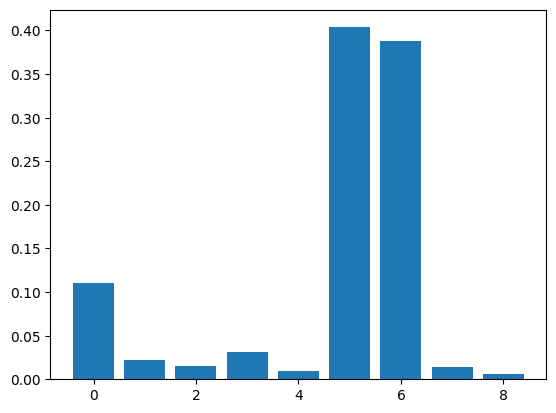

In [27]:
import matplotlib.pyplot as plt 

tictactoe = TicTacToe() 

state = tictactoe.get_initial_state() 
state = tictactoe.get_next_state(state, 1, -1) 
state = tictactoe.get_next_state(state, 2, -1) 
state = tictactoe.get_next_state(state, 3, 1) 
state = tictactoe.get_next_state(state, 4, 1) 

encoded_state = tictactoe.get_encoded_state(state) 

tensor_state = torch.tensor(encoded_state).unsqueeze(0)

model = ResNet(tictactoe, 4, 64) 

#load last model checkpoint
model.load_state_dict(torch.load('model_4.pt')) 
model.eval() 

policy,value = model(tensor_state) 
value = value.item() 
policy = torch.softmax(policy, axis = 1).squeeze(0).detach().cpu().numpy() 

print(value) 

print(state) 
print(tensor_state) 

plt.bar(range(tictactoe.action_size), policy) 
plt.show() 

Node class

In [5]:
class Node:
  def __init__(self, game, args, state, parent= None, action_taken = None, prior = 0):
    self.game = game
    self.args= args
    self.state = state
    self.parent = parent
    self.action_taken = action_taken
    self.prior = prior

    self.children = []

    self.visit_count = 0
    self.value_sum = 0

  def is_fully_expanded(self):
    return len(self.children) > 0

  def select(self):
    best_child = None
    best_ucb = -np.inf

    for child in self.children:
      ucb = self.get_ucb(child)
      if ucb > best_ucb:
        best_child = child
        best_ucb = ucb

      return best_child

  def get_ucb(self, child):
    if child.visit_count == 0:
      q_value = 0
    else:
      q_value = 1 - (( (child.value_sum / child.visit_count ) + 1 )  / 2)
    # not from the perspective of the parent and children,parent nodes represent different players
    # so if value from child perspective is near 0 this means that is probability
    # child loses, from parent perspective this is 1 so it takes this path
    return q_value + self.args['C'] * (math.sqrt((self.visit_count) / (child.visit_count+ 1) )) * child.prior

  def expand(self, policy):
    for action, prob in enumerate(policy):
      if prob > 0:
        child_state = self.state.copy()
        child_state = self.game.get_next_state(child_state, action, 1) #mcts never changes the player - but changes state of child since -ve represents opponent
        child_state = self.game.change_perspective(child_state, player = -1)

        child = Node(self.game, self.args, child_state, self, action, prob)
        self.children.append(child)


  def backpropogate(self,value):
    self.value_sum += value
    self.visit_count += 1

    value = self.game.get_opponent_value(value)
    if self.parent is not None:
      self.parent.backpropogate(value)


AlphaZero

In [15]:
class AlphaZero:
  def __init__(self, model, optimizer, game, args):
    self.model = model
    self.optimizer = optimizer
    self.game = game
    self.args = args
    self.mcts = MCTS(game, args,  model)

    #self play method 
  def selfPlay(self):
    #memory within one self play game
    memory = []
    player = 1
    state = self.game.get_initial_state()

    while True:
      neutral_state = self.game.change_perspective(state, player)
      action_probs = self.mcts.search(neutral_state)

      #store information in memory to gather data later for training
      memory.append((neutral_state, action_probs, player))

      #sample action from action_probs
      action = np.random.choice(self.game.action_size, p=action_probs)

      state = self.game.get_next_state(state, action, player)

      #check if terminal
      value, is_terminal = self.game.get_value_and_terminated(state, action)

      if is_terminal:
        returnMemory = []
        for hist_neutral_state, hist_action_probs, hist_player in memory:
          #generalise for other games --> use func get_opponent_value
          hist_outcome = value if hist_player == player else self.game.get_opponent_value(value)
          #encode state to input into model
          returnMemory.append((
               self.game.get_encoded_state(hist_neutral_state),
               hist_action_probs,
               hist_outcome
              ))
        return returnMemory

      player = self.game.get_opponent(player)

    #train method
  def train(self, memory): 
      #shuffle training data so batches are not always the same 
      random.shuffle(memory) 
      #loop over in batches --> for each batch index we can then sample a whole batch for each sample 
      for batchIdx in range(0, len(memory), self.args['batch_size']): 
          #take sample from memory 
          #min() in order to not exceed memory size 
          sample = memory[batchIdx:min(len(memory) -1, batchIdx + self.args['batch_size'])]
          #transpose samples -- tuples in memory include state, action and value 
          #by applying *, we get a list of states, actions and values 
          state, policy_targets, value_targets = zip(*sample) 
          #value_targets in an array include only float values 
          #value_targets are more helpful in the form of subarrays for comparison later 
          state, policy_targets, value_targets = np.array(state), np.array(policy_targets), np.array(value_targets).reshape(-1, 1)  
          #convert into tensors 
          state = torch.tensor(state, dtype = torch.float32) 
          policy_targets = torch.tensor(policy_targets, dtype = torch.float32) 
          value_targets = torch.tensor(value_targets, dtype = torch.float32) 
          #get outpolicy and outvalue from model by letting it predict the state 
          out_policy, out_value = self.model(state) 
          #loss for policy and value 
          policy_loss = F.cross_entropy(out_policy, policy_targets) 
          value_loss = F.mse_loss(out_value, value_targets) 
          #take sum of both losses to get one loss 
          loss = policy_loss + value_loss 
          #minimise loss by backpropogating 
          self.optimizer.zero_grad() 
          loss.backward() 
          #pytorch does backprogation and optmises model 
          self.optimizer.step() 

  #main method for continuous learning
  def learn(self):
    for iteration in range(self.args['num_iterations']):
      memory = []

      #prevent batch norms from being trained
      self.model.eval()
      #loop over self play games
      #trange --> for visualising each iteration
      for selfPlay_iteration in trange(self.args['num_selfPlay_iterations']):
        memory += self.selfPlay()

      self.model.train()
      for epoch in trange(self.args['num_epochs']):
        self.train(memory)

      #checkpoint model
      torch.save(self.model.state_dict(), f"model_{iteration}.pt")
      #checkpoint optimiser
      torch.save(self.optimizer.state_dict(), f"optimizer_{iteration}.pt")

check implementation so far

In [22]:
tictactoe = TicTacToe()
model = ResNet(tictactoe, 4, 64)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
args = {
    'C': 2,
    'num_searches': 60,
    'num_iterations': 5,
    'num_selfPlay_iterations': 500,
    'num_epochs': 4,
    'batch_size': 64
}

alphazero = AlphaZero(model, optimizer, tictactoe, args)
alphazero.learn() 

100%|████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:03<00:00,  1.04it/s]


Main

In [8]:
tictactoe = TicTacToe()
player = 1

args = {
    'C': 2,
    'num_searches': 1000
}

model = ResNet(tictactoe, 4, 64)

model.eval()

mcts = MCTS(tictactoe, args, model)

state = tictactoe.get_initial_state()


while True:
    print(state)
    if player == 1:
      valid_moves = tictactoe.get_valid_moves(state)
      print("valid_moves", [i for i in range(tictactoe.action_size) if valid_moves[i] == 1])
      action = int(input(f"{player}: "))

      if valid_moves[action] == 0:
          print("action not valid")
          continue

    else:
      neutral_state = tictactoe.change_perspective(state, player)
      mcts_probs = mcts.search(neutral_state)
      action = np.argmax(mcts_probs)

    state = tictactoe.get_next_state(state, action, player)

    value, is_terminal = tictactoe.get_value_and_terminated(state, action)

    if is_terminal:
        print(state)
        if value == 1:
            print(player, "won")
        else:
            print("draw")
        break

    player = tictactoe.get_opponent(player)


[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]
valid_moves [0, 1, 2, 3, 4, 5, 6, 7, 8]


1:  1


[[0. 1. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]
[[-1.  1.  0.]
 [ 0.  0.  0.]
 [ 0.  0.  0.]]
valid_moves [2, 3, 4, 5, 6, 7, 8]


1:  5


[[-1.  1.  0.]
 [ 0.  0.  1.]
 [ 0.  0.  0.]]
[[-1.  1. -1.]
 [ 0.  0.  1.]
 [ 0.  0.  0.]]
valid_moves [3, 4, 6, 7, 8]


1:  4


[[-1.  1. -1.]
 [ 0.  1.  1.]
 [ 0.  0.  0.]]
[[-1.  1. -1.]
 [-1.  1.  1.]
 [ 0.  0.  0.]]
valid_moves [6, 7, 8]


1:  7


[[-1.  1. -1.]
 [-1.  1.  1.]
 [ 0.  1.  0.]]
1 won
